[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sear-labs/energy-system-modeling/blob/main/notebooks/p2_demand/06_end_use_disaggregation.ipynb)

# One-node disaggregation and demand-side technologies
## REE 4301 — Energy Systems Modeling
### Bridges Module 1 (Demand) into Module 2 (Generation)

**Objective:** The 1-node capacity expansion model you already ran treats demand as one aggregate curve. Real demand-side technologies — weatherization, efficiency upgrades, heat pumps — don't act on the aggregate; they act on one end use at a time. In this assignment you will disaggregate your own demand profile into named end uses, apply a demand-side technology to one of them, and see how that changes the supply-side optimum the solver chooses.

**What You Will Learn:**
- How to separate weather-sensitive load (heating, cooling) from the weather-insensitive baseline using the same degree-day regression method from Mini-Project 1 — not a new method, the same one
- How to name and shape individual end uses within an aggregate profile
- How a demand-side choice (insulation, efficiency, fuel switching) changes what the generation-side solver builds
- Why you have to say what fuel an end use currently uses before you can talk about switching it

**Builds on:** the 1-node baseline you already ran and replaced with your own demand profile. If you have not done that yet, Part 1 below is that step, unchanged.

**Standard submission requirements apply** — see Part One of the Assignment Catalogue: units on every number, cite your data source and its year, print to PDF with text cells intact, also submit the .ipynb.


## Setup

One cell, the same in every notebook here: it installs what Colab does not have, fetches this repository so `data/` and `src/` are present, and moves into this notebook's own folder so the relative paths below resolve. The notebook's own imports follow in the same cell.


In [1]:
# --- setup: generated by tools/sync_setup_cells.py -- do not edit here, edit that
# The same cell in every notebook in this series. It installs what Colab does
# not have, fetches the repository so that data/ and src/ are present, and moves
# into this notebook's own folder so the relative paths below resolve.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/sear-labs/energy-system-modeling"
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1]
NOTEBOOK_DIR = "notebooks/p2_demand"

# Pinned, per Part 1 rule 3: an unpinned install will one day pull a major
# version with a changed API and either break or silently alter the answer.
PINS = ["gurobipy>=11,<14", "highspy>=1.11,<2", "pypsa>=1.3,<2"]

if "google.colab" in sys.modules:
    if PINS:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PINS], check=True)
    # An ABSOLUTE base, so re-running this cell is safe. Colab's "Run all" is
    # commonly run twice, and a relative check would look for the clone inside
    # the folder it had already moved into -- cloning a second copy nested one
    # level down, then working from the wrong one.
    BASE = Path("/content") if Path("/content").is_dir() else Path.home()
    REPO_DIR = BASE / REPO_NAME
    if not REPO_DIR.exists():
        cloned = subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, str(REPO_DIR)],
            capture_output=True, text=True)
        if cloned.returncode != 0:
            raise SystemExit(
                "Could not clone " + REPO_URL + "\n"
                + (cloned.stderr or "").strip() + "\n\n"
                "If that says 'not found', the repository is still private.\n"
                "A raw file URL fails the same way, so there is no way around\n"
                "it: it has to be public before a student can run this.")
    os.chdir(REPO_DIR / NOTEBOOK_DIR)
elif Path.cwd().name != Path(NOTEBOOK_DIR).name:
    raise SystemExit(
        "Run this notebook from its own folder (" + NOTEBOOK_DIR + "),\n"
        "so that ../../src and ../../data resolve.")

sys.path.insert(0, str(Path.cwd().parents[1] / "src"))
print("working directory:", Path.cwd().name)

# --- end generated setup; the notebook's own imports follow ---


working directory: p2_demand


---
## Part 0 — Setup & Baseline

This is the **exact same 1-node model** from the reference notebook (`capacity-expansion-planning-single-node.ipynb`), wrapped in a function so Parts 1–3 can re-run it with different demand series. **Do not modify these cells** — everything you do happens from Part 1 onward.


In [2]:
# General notebook settings
import logging
import warnings

import pypsa
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import io

warnings.filterwarnings("ignore")
logging.getLogger("gurobipy").propagate = False
pypsa.options.params.optimize.log_to_console = False
pd.set_option("display.float_format", "{:,.2f}".format)


---

### Choosing a solver



This notebook defaults to **Gurobi**. `pip install gurobipy` ships a restricted licence that needs no registration at all and solves models up to **2,000 variables and 2,000 constraints**.



That ceiling arrives sooner than you would think. Measured sizes for the models in this course:



| model | variables | constraints | restricted licence |

|---|---|---|---|

| 1-node, 24 hours | 123 | 291 | fits |

| SB6 Stage 1 | 766 | 1,837 | fits |

| SB6 Stage 2 | 886 | 2,172 | too big |

| SB6 Stage 3 | 2,614 | 6,444 | too big |

| TX-123BT, 24 hours | 16,080 | 38,304 | 19x over |



When you exceed it, Gurobi returns *"Model too large for size-limited license"*. Two ways past it:



**In class — switch to HiGHS.** Open source, no licence, no size limit. Uncomment the `SOLVER` line below. There is no accuracy cost: HiGHS and Gurobi agree to sixteen significant figures on every model here. The speed cost is real only when the problem is large — measured on a 1-node model, HiGHS is *marginally faster* at 24 hours, identical at one week, and about **12x slower** on a full 8,760-hour year (22 s against 1.8 s). On a mixed-integer unit-commitment problem with 2,880 binary variables the gap was only **1.8x**.



**For homework — get an academic licence.** A free Web License Service (WLS) key from gurobi.com works in Colab with **no licence file**: paste the three values into `WLS` below. Build the environment **once** and reuse it — constructing a new one for every solve re-authenticates each time and will exhaust a WLS session partway through a scenario sweep.



In [3]:
SOLVER = 'gurobi'

# SOLVER = 'highs'     # <-- uncomment: open source, no licence, no size cap



# For homework: paste your academic Web License Service key here.

# Leave it empty and Gurobi falls back to its restricted licence.

WLS = {}   # {'WLSACCESSID': '...', 'WLSSECRET': '...', 'LICENSEID': 000000}



ENV = None

if SOLVER == 'gurobi' and WLS:

    import gurobipy as gp

    ENV = gp.Env(params=WLS)     # ONE environment, reused by every solve



print(f'solver: {SOLVER}'

      + ('  (academic WLS licence)' if ENV else '  (default licence)'))



solver: gurobi  (default licence)


### Techno-economic assumptions
Same source as the reference notebook: the [technology-data](https://github.com/PyPSA/technology-data) repository.


In [4]:
YEAR = 2030
# PINNED, per Part 1 rule 3. This URL used to read `master`, which is not
# a version: on 2026-09-13 master, v0.15.0 and v0.13.2 of costs_2030.csv
# were three different files (283,889 / 281,355 / 268,002 bytes). A
# notebook reading master gives whatever upstream happened to have that
# morning, so its answers are not reproducible even to the day.
#
# The tables are GPL-3.0 -- a copyleft licence, read here rather than
# vendored. See data/vendor/README.md.
TECH_DATA_VERSION = 'v0.15.0'
url = (f'https://raw.githubusercontent.com/PyPSA/technology-data/'
       f'{TECH_DATA_VERSION}/outputs/costs_{YEAR}.csv')
costs = pd.read_csv(url, index_col=[0, 1])
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs = costs.value.unstack().fillna(
    {"discount rate": 0.07, "lifetime": 20, "FOM": 0}
)
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

def annuity(rate, n):
    """Capital recovery factor for a given discount rate and lifetime - the same CRF from Module 2."""
    if rate == 0:
        return 1 / n
    return rate / (1 - (1 + rate) ** (-n))

a = costs.apply(lambda x: annuity(x["discount rate"], x["lifetime"]), axis=1)
costs["capital_cost"] = (a + costs["FOM"] / 100) * costs["investment"]


### Reference wind, solar and demand time series
This is the same representative-year wind/solar capacity-factor series the reference notebook uses. Your own demand (Part 1) gets spliced onto this same calendar of hours.


In [5]:
RESOLUTION = 3  # hours, matches the reference notebook
URL = "https://tubcloud.tu-berlin.de/s/9toBssWEdaLgHzq/download/time-series.csv"

# pandas reads a URL through urllib, which uses the SYSTEM certificate store.
# This host serves an incomplete chain, so verification stops at "unable to get
# local issuer certificate" and the notebook dies on a stack trace. requests
# carries certifi's own bundle and completes the chain, so the download happens
# here and pandas is handed text.
#
# The series is also on a personal share link with no stated licence, and is
# due to be replaced with a citable source - see data/vendor/README.md.
try:
    _resp = requests.get(URL, timeout=60)
    _resp.raise_for_status()
except Exception as exc:
    raise RuntimeError(
        f"Could not download the reference time series.\n"
        f"  {type(exc).__name__}: {exc}\n"
        "This cell needs network access. The series carries wind_pu, pv_pu "
        "and load_mw on an hourly calendar; data/vendor/README.md describes "
        "the replacement that is due to remove this dependency."
    ) from exc

ts = pd.read_csv(io.StringIO(_resp.text), index_col=0,
                 parse_dates=True)[::RESOLUTION]
print(f"{len(ts):,} snapshots at {RESOLUTION}h, "
      f"{ts.index[0]:%Y-%m-%d} to {ts.index[-1]:%Y-%m-%d}")
ts.head(3)


2,920 snapshots at 3h, 2019-01-01 to 2019-12-31


,load_mw,pv_pu,wind_pu
timestamp,,,
2019-01-01 00:00:00,"5,719.26",0.00,0.18
2019-01-01 03:00:00,"5,474.74",0.00,0.31
2019-01-01 06:00:00,"5,413.39",0.00,0.50


### `build_1node_model()` — the reusable model builder
Identical construction to the reference notebook (electricity bus, load, load-shedding generator, wind, solar, 3-hour battery, hydrogen electrolysis/turbine/storage) — just wrapped in a function so you can call it again with a different `demand_mw` series without retyping it.


In [6]:
def build_1node_model(demand_mw, label="model"):
    """demand_mw: a pandas Series indexed exactly like ts.index, in MW."""
    n = pypsa.Network()
    n.add("Bus", "electricity", carrier="electricity")
    n.set_snapshots(ts.index)
    n.snapshot_weightings.loc[:, :] = RESOLUTION

    carriers = ["wind", "solar", "hydrogen storage", "battery storage",
                "load shedding", "electrolysis", "turbine",
                "electricity", "hydrogen"]
    colors = ["dodgerblue", "gold", "black", "yellowgreen", "darkorange",
              "magenta", "red", "grey", "grey"]
    n.add("Carrier", carriers, color=colors)

    n.add("Load", "demand", bus="electricity", p_set=demand_mw)

    n.add("Generator", "load shedding", bus="electricity",
          carrier="load shedding", marginal_cost=2000,
          p_nom=demand_mw.max())

    n.add("Generator", "wind", bus="electricity", carrier="wind",
          p_max_pu=ts.wind_pu, capital_cost=costs.at["onwind", "capital_cost"],
          marginal_cost=costs.at["onwind", "marginal_cost"], p_nom_extendable=True)

    n.add("Generator", "solar", bus="electricity", carrier="solar",
          p_max_pu=ts.pv_pu, capital_cost=costs.at["solar", "capital_cost"],
          marginal_cost=costs.at["solar", "marginal_cost"], p_nom_extendable=True)

    n.add("StorageUnit", "battery storage", bus="electricity",
          carrier="battery storage", max_hours=3,
          capital_cost=costs.at["battery inverter", "capital_cost"]
          + 3 * costs.at["battery storage", "capital_cost"],
          efficiency_store=costs.at["battery inverter", "efficiency"],
          efficiency_dispatch=costs.at["battery inverter", "efficiency"],
          p_nom_extendable=True, cyclic_state_of_charge=True)

    n.add("Bus", "hydrogen", carrier="hydrogen")
    n.add("Link", "electrolysis", bus0="electricity", bus1="hydrogen",
          carrier="electrolysis", p_nom_extendable=True,
          efficiency=costs.at["electrolysis", "efficiency"],
          capital_cost=costs.at["electrolysis", "capital_cost"])
    n.add("Link", "turbine", bus0="hydrogen", bus1="electricity",
          carrier="turbine", p_nom_extendable=True,
          efficiency=costs.at["OCGT", "efficiency"],
          capital_cost=costs.at["OCGT", "capital_cost"] / costs.at["OCGT", "efficiency"])
    n.add("Store", "hydrogen storage", bus="hydrogen", carrier="hydrogen storage",
          capital_cost=costs.at["hydrogen storage underground", "capital_cost"],
          e_nom_extendable=True, e_cyclic=True)

    n.name = label
    return n


In [7]:
def extract_results(n, label=""):
    """Pull the headline numbers out of a solved network."""
    cap = n.statistics.optimal_capacity().droplevel(0)
    bal = n.statistics.energy_balance(bus_carrier="electricity").droplevel(0)
    served = n.loads_t.p_set["demand"].sum() * RESOLUTION
    shed = n.generators_t.p["load shedding"].sum() * RESOLUTION
    return {
        "Scenario": label,
        "Total system cost ($M)": n.objective / 1e6,
        "Wind (MW)": cap.get("wind", 0.0),
        "Solar (MW)": cap.get("solar", 0.0),
        "Battery (MW)": cap.get("battery storage", 0.0),
        "Total demand (MWh)": served,
        "Unserved energy (MWh)": shed,
        "Unserved (%)": 100 * shed / served if served else 0.0,
    }

def compare_scenarios(results_list):
    return pd.DataFrame(results_list).set_index("Scenario").T


---
## Part 1 — Baseline run and your own demand

If you already completed the original 1-Node Assignment, this is the same step — reproduced here so this notebook stands on its own and so `r_reference` and `r_own` are available for the comparison table at the end of Part 3.


In [8]:
n_reference = build_1node_model(ts.load_mw, "Reference demand")
n_reference.optimize(solver_name=SOLVER, env=ENV)
r_reference = extract_results(n_reference, "Reference demand")
compare_scenarios([r_reference])


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/21 [00:00<?, ?it/s]

Writing constraints.:  95%|█████████▌| 20/21 [00:00<00:00, 198.67it/s]

...

obj: 64246 rows, 29206 columns, 124144 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 1.01e+10
Solver: gurobi
Runtime: 1.50s
Dual bound: 1.01e+10
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Scenario,Reference demand
Total system cost ($M),"10,132.59"
Wind (MW),"32,583.32"
Solar (MW),"26,089.52"
Battery (MW),"14,047.95"
Total demand (MWh),"66,266,089.12"
Unserved energy (MWh),"145,412.44"
Unserved (%),0.22


### TODO — load your own demand profile

Replace `DEMAND_CSV_PATH` with your own Mini-Project 1 / smart-meter export — an ERCOT-style 15-minute interval CSV with `USAGE_DATE`, `USAGE_START_TIME` and `USAGE_KWH` columns.

**If that file is not next to the notebook** — which it will not be the first time you open this in Colab — the cell below falls back to a synthetic residential profile so the rest of the notebook still runs. It will say loudly that it has done so. **A synthetic profile is not an acceptable submission**; upload your own export before you write anything up.

**State your assumption:** the reference wind/solar series and your own demand almost certainly come from different calendar years. This notebook aligns them by **day-of-year and hour-of-day**, not by exact date — i.e. it assumes your demand *shape* is representative regardless of which year it was metered in. Say so explicitly in your write-up; it is a real modelling assumption, not a bug.


NO FILE NAMED IntervalData.csv FOUND - using a SYNTHETIC profile.
The rest of the notebook will run, but this is not your data
and it is not an acceptable submission. Upload your own
interval export and re-run from this cell.


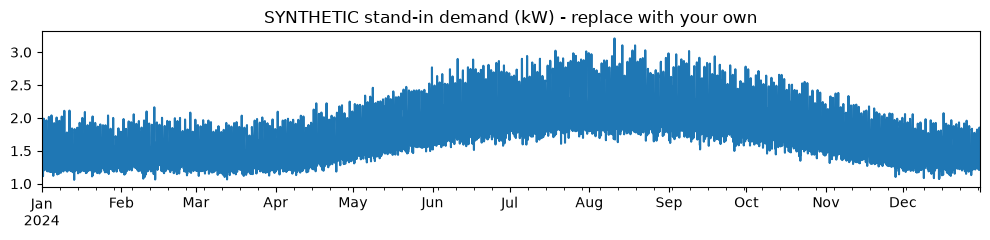

In [9]:
DEMAND_CSV_PATH = "IntervalData.csv"  # <-- point this at your own export

def load_own_demand(path):
    """ERCOT-style 15-minute interval export -> hourly-mean kW, indexed by real timestamp."""
    raw = pd.read_csv(path)
    raw["ts"] = pd.to_datetime(
        raw["USAGE_DATE"] + " " + raw["USAGE_START_TIME"],
        format="%m/%d/%Y %H:%M",
    )
    kwh_15min = raw.set_index("ts")["USAGE_KWH"]
    kw_hourly = kwh_15min.resample("1h").sum() * 4  # 15-min kWh -> hourly-avg kW
    return kw_hourly


def synthetic_demand(days=365):
    """Stand-in profile: morning and evening peaks, warmer-month cooling.
    Used ONLY when no interval file is present, so the notebook still runs.
    """
    idx = pd.date_range('2024-01-01', periods=days * 24, freq='1h')
    hour = idx.hour.to_numpy()
    doy = idx.dayofyear.to_numpy()
    shape = (0.9
             + 0.45 * np.exp(-((hour - 19) ** 2) / 6.0)
             + 0.20 * np.exp(-((hour - 7) ** 2) / 4.0))
    cooling = 1 + 0.5 * np.clip(np.sin(np.pi * (doy - 100) / 240), 0, 1)
    rng = np.random.default_rng(0)
    kw = 1.4 * shape * cooling * rng.normal(1.0, 0.05, len(idx))
    return pd.Series(np.clip(kw, 0.15, None), index=idx)

try:
    own_demand_kw = load_own_demand(DEMAND_CSV_PATH)
    DEMAND_IS_REAL = True
    print(f'loaded {DEMAND_CSV_PATH}: {len(own_demand_kw):,} hourly points')
except FileNotFoundError:
    own_demand_kw = synthetic_demand()
    DEMAND_IS_REAL = False
    print('=' * 66)
    print(f'NO FILE NAMED {DEMAND_CSV_PATH} FOUND - using a SYNTHETIC profile.')
    print('The rest of the notebook will run, but this is not your data')
    print('and it is not an acceptable submission. Upload your own')
    print('interval export and re-run from this cell.')
    print('=' * 66)

title = ('Your metered demand (kW)' if DEMAND_IS_REAL
         else 'SYNTHETIC stand-in demand (kW) - replace with your own')
own_demand_kw.plot(figsize=(10, 2.5), title=title)
plt.tight_layout(); plt.show()


In [10]:
def align_to_reference_calendar(series_kw, target_index, scale_to_mw=1e-3):
    """Map a demand series onto the reference model's snapshot calendar by (month, day, hour) rather than exact date, since the two data sources are almost never the same year. Returns MW, indexed like target_index."""
    by_time = series_kw.groupby(
        [series_kw.index.month, series_kw.index.day, series_kw.index.hour]
    ).mean()
    keys = list(zip(target_index.month, target_index.day, target_index.hour))
    mapped = pd.Series([by_time.get(k, np.nan) for k in keys], index=target_index)
    mapped = mapped.interpolate().bfill().ffill()  # cover any Feb 29 / missing hours
    return mapped * scale_to_mw

one_premise_mw = align_to_reference_calendar(own_demand_kw, ts.index)

print(f'one premise: peak {one_premise_mw.max()*1e3:,.1f} kW,'
      f'  annual {one_premise_mw.sum()*RESOLUTION*1e3:,.0f} kWh')


one premise: peak 3.0 kW,  annual 14,971 kWh


### Your meter is the shape. It is not the scale.

**Read this before going further, because everything downstream depends on it.**

What you just plotted is one metered premise — a house, or one building. The model it is about to enter builds wind farms and grid batteries. Solving a capacity expansion for a single house against that cost library is not wrong so much as **meaningless**: you would be asking what utility-scale fleet to build for a 20 kW load, and the answer would be dominated by rounding.

So use your meter for what it is genuinely good for — **the shape**. When load rises and falls, how it responds to weather, how peaky it is. That shape is real, it is yours, and it is the thing no textbook can give you.

Then **state a scale separately**, and defend it. You are modelling a development made of premises like yours: a neighbourhood, an apartment complex, a mixed-use block.


In [11]:
# ---------------- the shape is yours. the scale is a decision. -----------
N_PREMISES = 2_000     # <-- STATE AND DEFEND THIS

DEVELOPMENT = ('a mixed-use development of roughly 2,000 premises like '
               'the metered one - call it 1,500 dwellings plus commercial '
               'and common-area load')
# -------------------------------------------------------------------------

site_demand_mw = one_premise_mw * N_PREMISES

print(DEVELOPMENT)
print()
print(f'  peak demand    {site_demand_mw.max():>8,.1f} MW')
print(f'  annual energy  {site_demand_mw.sum()*RESOLUTION/1e3:>8,.1f} GWh')
print(f'  load factor    {site_demand_mw.mean()/site_demand_mw.max():>8.2f}')


a mixed-use development of roughly 2,000 premises like the metered one - call it 1,500 dwellings plus commercial and common-area load

  peak demand         6.1 MW
  annual energy      29.9 GWh
  load factor        0.56


Check that number against something you know before you use it. A real development lands in the **megawatts** — single digits for a residential block, a few tens for something the size of the Metroplex Industrial Park you meet in Module 0B, which is 50 MW. A peak of 0.02 MW means you forgot to scale. A peak of 5,000 MW means you have accidentally built a city, and should either say so or reduce `N_PREMISES`.

The load factor is the other check. Somewhere near 0.5 is ordinary for a mixed residential load. Close to 1.0 means your profile is nearly flat, which is worth explaining before Part 3 — a flat load gives a demand-side measure very little expensive peak to bite into.

**Two things to state in your write-up, because both are assumptions and neither is free:**

1. **Where `N_PREMISES` came from.** A dwelling count from a site plan, a floor area divided by an intensity, a real development you looked up. "2,000 because it made the numbers look nice" is not a defence.
2. **That you assumed perfect coincidence.** Multiplying one profile by 2,000 assumes every premise peaks *at the same instant*. Real developments do not: individual peaks scatter, so an actual aggregate peak is lower and flatter than this. Your model therefore **overstates peakiness**, which biases it toward peaking capacity and storage, and — importantly for Part 3 — **overstates what a demand-side measure is worth**, because it inflates the expensive hours the measure gets to displace.

If you want to correct for that rather than just declare it, the cell below shrinks the variation around the mean while holding total energy fixed. It is a crude stand-in for diversity, so say that it is one.


In [12]:
COINCIDENCE = 1.00   # 1.00 = no correction (and say so).
                     # ~0.6 is a common residential aggregate figure -
                     # cite one if you use it.

mean_mw = site_demand_mw.mean()
site_demand_mw = mean_mw + (site_demand_mw - mean_mw) * COINCIDENCE

print(f'after a coincidence factor of {COINCIDENCE:.2f}:')
print(f'  peak demand    {site_demand_mw.max():>8,.1f} MW')
print(f'  annual energy  {site_demand_mw.sum()*RESOLUTION/1e3:>8,.1f} GWh'
      f'   (unchanged - the correction moves the peak, not the energy)')
print(f'  load factor    {site_demand_mw.mean()/site_demand_mw.max():>8.2f}')


after a coincidence factor of 1.00:
  peak demand         6.1 MW
  annual energy      29.9 GWh   (unchanged - the correction moves the peak, not the energy)
  load factor        0.56


Now solve it. This is the same model as the reference run — only the demand series changed.


In [13]:
n_own = build_1node_model(site_demand_mw, "Your development (Part 1)")
n_own.optimize(solver_name=SOLVER, env=ENV)
r_own = extract_results(n_own, "Your development (Part 1)")
compare_scenarios([r_reference, r_own])


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/21 [00:00<?, ?it/s]

Writing constraints.: 100%|██████████| 21/21 [00:00<00:00, 224.80it/s]

...

obj: 64246 rows, 29206 columns, 124144 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 4.62e+06
Solver: gurobi
Runtime: 1.54s
Dual bound: 4.62e+06
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Scenario,Reference demand,Your development (Part 1)
Total system cost ($M),"10,132.59",4.62
Wind (MW),"32,583.32",9.13
Solar (MW),"26,089.52",21.61
Battery (MW),"14,047.95",14.46
Total demand (MWh),"66,266,089.12","29,941.36"
Unserved energy (MWh),"145,412.44",67.67
Unserved (%),0.22,0.23


**Report:** how does the optimal build (wind/solar/battery MW) and total system cost change between the reference demand and your own? State one reason your demand's *shape* — not just its total — drives that difference.


---
## Part 2 — Disaggregate the load

The 1-node model treats demand as one curve. Every demand-side technology this course names — weatherization, efficiency upgrades, heat pumps — acts on one **end use**, not the aggregate. This part splits your own demand into named end uses using two steps:

1. **Weather-sensitive vs. baseline split** — the same degree-day regression method from Mini-Project 1, applied to your own profile instead of a new method.
2. **Named end-use split** — cited typical shares, applied to divide the regression's two components into the categories a technology can actually target.

**Cited reference shares** (state these in your write-up, or replace them with your own source): the three largest US residential electricity end uses are air conditioning (19%), space heating (12%), and water heating (12%) of site electricity consumption — EIA, *Residential Energy Consumption Survey* 2020 (eia.gov/energyexplained/use-of-energy/electricity-use-in-homes.php). The remainder (57%) is lighting, refrigeration, electronics and other plug loads — EIA does not break this remainder down further at the site-electricity level, so it is treated here as one **baseline** category. If you have access to a finer-grained source (NREL ResStock/ComStock, or your own utility's disaggregation), cite it and split baseline further.


In [14]:
# Real daily-mean temperature for your metering period, fetched live -
# no API key required. Update LAT/LON to your own city.
LAT, LON = 32.7767, -96.7970  # Dallas, TX — change to your own location

def fetch_daily_temp_f(start_date, end_date, lat=LAT, lon=LON):
    url = (
        "https://archive-api.open-meteo.com/v1/archive"
        f"?latitude={lat}&longitude={lon}"
        f"&start_date={start_date}&end_date={end_date}"
        "&daily=temperature_2m_mean&temperature_unit=fahrenheit&timezone=auto"
    )
    r = requests.get(url, timeout=30).json()["daily"]
    return pd.Series(r["temperature_2m_mean"],
                      index=pd.to_datetime(r["time"]), name="temp_f")

daily_kwh = own_demand_kw.resample("1D").sum()
start, end = daily_kwh.index.min().date(), daily_kwh.index.max().date()
temp_f = fetch_daily_temp_f(str(start), str(end))
temp_f = temp_f.reindex(daily_kwh.index).interpolate()


In [15]:
BASE_TEMP_F = 65  # standard degree-day base, same as Module 1
hdd = (BASE_TEMP_F - temp_f).clip(lower=0)
cdd = (temp_f - BASE_TEMP_F).clip(lower=0)

# Regress daily kWh on HDD and CDD - the same method Mini-Project 1 used.
X = np.column_stack([np.ones(len(daily_kwh)), hdd.values, cdd.values])
beta, *_ = np.linalg.lstsq(X, daily_kwh.values, rcond=None)
baseline_kwh_per_day, heat_slope, cool_slope = beta

pred = X @ beta
ss_res = ((daily_kwh.values - pred) ** 2).sum()
ss_tot = ((daily_kwh.values - daily_kwh.values.mean()) ** 2).sum()
r2 = 1 - ss_res / ss_tot
print(f"Weather-insensitive baseline: {baseline_kwh_per_day:,.1f} kWh/day")
print(f"Heating slope: {heat_slope:,.2f} kWh per HDD")
print(f"Cooling slope: {cool_slope:,.2f} kWh per CDD")
print(f"R-squared: {r2:.2f}  (Module 1's own regression on real smart-meter "
      "data got cooling R2=0.68, heating R2=0.21 - a weak heating fit is "
      "common, not a sign you did it wrong)")


Weather-insensitive baseline: 36.0 kWh/day
Heating slope: -0.08 kWh per HDD
Cooling slope: 0.65 kWh per CDD
R-squared: 0.81  (Module 1's own regression on real smart-meter data got cooling R2=0.68, heating R2=0.21 - a weak heating fit is common, not a sign you did it wrong)


0 of 365 days have a NEGATIVE implied baseline (fitted heating+cooling exceeds actual usage that day).
This is a real, common artifact of a linear degree-day fit on real data - not a bug, and not something to clip away. It usually means those days had unusually low occupancy/usage relative to the outdoor temperature. Report the count in your write-up rather than silently fixing it; clipping it to zero would break the reconciliation-to-total this course requires.
Annual share of each end use:
heating            0.0%
cooling           13.4%
water_heating     15.1%
other_baseline    71.5%
dtype: str


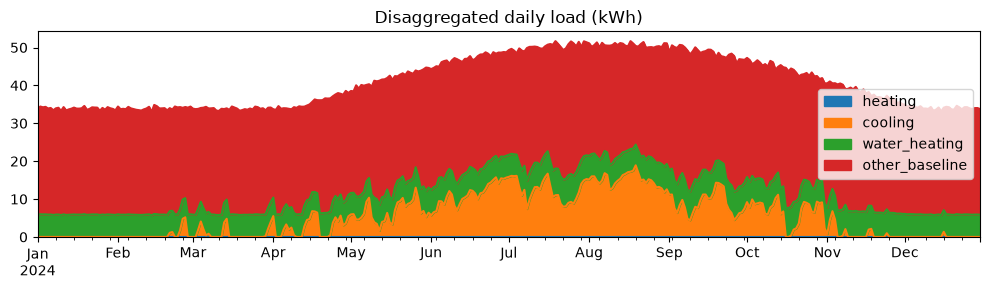

In [16]:
# Reconstruct daily end-use series that sum back to the metered total.
heating_kwh = (heat_slope * hdd).clip(lower=0)
cooling_kwh = (cool_slope * cdd).clip(lower=0)
baseline_total_kwh = daily_kwh - heating_kwh - cooling_kwh

n_negative_days = (baseline_total_kwh < 0).sum()
print(f"{n_negative_days} of {len(baseline_total_kwh)} days have a "
      "NEGATIVE implied baseline (fitted heating+cooling exceeds actual "
      "usage that day).")
print("This is a real, common artifact of a linear degree-day fit on "
      "real data - not a bug, and not something to clip away. It "
      "usually means those days had unusually low occupancy/usage "
      "relative to the outdoor temperature. Report the count in your "
      "write-up rather than silently fixing it; clipping it to zero "
      "would break the reconciliation-to-total this course requires.")

# EIA RECS 2020 shares (cited above) split the weather-insensitive
# baseline into water heating vs. everything else.
SHARE_WATER_HEATING_OF_BASELINE = 0.12 / (1 - 0.19 - 0.12)  # 12% of total,
                                                              # renormalized
                                                              # onto baseline
water_heating_kwh = baseline_total_kwh * SHARE_WATER_HEATING_OF_BASELINE
other_baseline_kwh = baseline_total_kwh - water_heating_kwh

end_uses = pd.DataFrame({
    "heating": heating_kwh, "cooling": cooling_kwh,
    "water_heating": water_heating_kwh, "other_baseline": other_baseline_kwh,
})
assert np.allclose(end_uses.sum(axis=1), daily_kwh, atol=1e-6), \
    "end uses must reconcile back to the metered total"

print("Annual share of each end use:")
print((end_uses.sum() / end_uses.sum().sum() * 100).round(1).astype(str) + "%")
end_uses.plot.area(figsize=(10, 3), title="Disaggregated daily load (kWh)")
plt.tight_layout(); plt.show()


**Report:**
- Your own annual share for each end use, next to the EIA reference shares. Where do they agree or disagree, and what about your specific home/meter could explain a disagreement (climate, home size, heating fuel, occupancy)?
- The count of negative-implied-baseline days printed above, and one sentence on what it tells you about the limits of a linear degree-day fit.


---
## Part 3 — Add a demand-side technology

There are two ways to put a demand-side measure into this model, and they answer **different questions**. You are going to do both, in that order, because the difference between them is the whole point of this part.

1. **Cut the demand series and re-solve.** Asks: *if demand were 30% lower, what would we build?*
2. **Offer the measure to the solver as something it may buy.** Asks: *is this measure worth building at all, and at what price does that stop being true?*

The first assumes the answer to the second. Only the second is an investment decision, and only the second can tell you that a measure is **not** worth doing.


### 3.1 First, the version that looks obvious

Weatherization improves the building envelope, so it reduces the heating and cooling end uses. The direct way to model that is to multiply those two columns down and re-solve.

**Cite your cut factor.** The DOE Weatherization Assistance Program reports roughly a 30% average heating-cost reduction in cold-weather states (energy.gov; ACEEE WAP fact sheet). It is applied to cooling as well here, since the envelope affects both — say in your write-up if you think cooling deserves a different factor.


In [17]:
CUT_PCT = 0.30   # <-- your cut factor, cited

cut_end_uses = end_uses.copy()
cut_end_uses['heating'] *= (1 - CUT_PCT)
cut_end_uses['cooling'] *= (1 - CUT_PCT)

# Rescale each hour by that day's change in total, keeping the intraday
# shape. A full appliance-level reshape is out of scope - name that as a
# limitation in your write-up.
daily_ratio = (cut_end_uses.sum(axis=1) / daily_kwh).reindex(
    own_demand_kw.index.floor('D')).values
cut_demand_kw = pd.Series(own_demand_kw.values * daily_ratio,
                          index=own_demand_kw.index)
cut_demand_mw = align_to_reference_calendar(cut_demand_kw, ts.index) * N_PREMISES

print(f'peak demand   before {site_demand_mw.max():,.1f} MW'
      f'   after {cut_demand_mw.max():,.1f} MW')


peak demand   before 6.1 MW   after 5.6 MW


In [18]:
n_cut = build_1node_model(cut_demand_mw, 'Demand cut exogenously')
n_cut.optimize(solver_name=SOLVER, env=ENV)
r_cut = extract_results(n_cut, 'Demand cut exogenously')

compare_scenarios([r_reference, r_own, r_cut])


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/21 [00:00<?, ?it/s]

Writing constraints.: 100%|██████████| 21/21 [00:00<00:00, 208.18it/s]

...

obj: 64246 rows, 29206 columns, 124144 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 29206 primals, 64246 duals
Objective: 4.42e+06
Solver: gurobi
Runtime: 1.56s
Dual bound: 4.42e+06
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


Scenario,Reference demand,Your development (Part 1),Demand cut exogenously
Total system cost ($M),"10,132.59",4.62,4.42
Wind (MW),"32,583.32",9.13,9.48
Solar (MW),"26,089.52",21.61,19.36
Battery (MW),"14,047.95",14.46,12.95
Total demand (MWh),"66,266,089.12","29,941.36","28,737.81"
Unserved energy (MWh),"145,412.44",67.67,61.68
Unserved (%),0.22,0.23,0.21


Now say precisely what that told you.

It told you what the system builds **given** a 30% cut. It did not tell you whether the 30% cut was worth paying for, because nothing in the model knew what it cost. You supplied that answer as an input and the model priced everything else around it.

That is a legitimate scenario study. It is not an investment decision. Notice too that the measure could not decline gracefully: you got exactly 30%, in every hour, whether or not it was earning its keep in that hour.


### 3.2 The same measure, as something the solver can buy

Here is the reframe that matters. **To an optimizer, a negawatt and a megawatt are the same object.** A megawatt of wind and a megawatt of avoided heating load both help close `Bus-nodal_balance`; both cost money to build; both are only available at certain hours. So model the measure the way you already model a generator.

Every investable resource in this model is defined by exactly three things, and weatherization has all three:

| | wind | weatherization |
|---|---|---|
| what it costs to build | `capital_cost` from technology-data | annualised cost of the retrofit |
| when it is available | `p_max_pu` = the wind profile | `p_max_pu` = the heating + cooling load shape |
| how much you can have | site and land limits | you cannot save more than the end use consumes |

The availability profile is the part people get wrong. Weatherization cannot deliver a negawatt in a mild week — there is no heating load to avoid. Its output is capped, hour by hour, by the size of the end use it displaces.


A word on units. Everything from here is in **MW**, because you scaled your single premise up to a development in Part 1 — that is what made this model worth solving. If a number below comes out in the hundredths, check `N_PREMISES`: you are probably still modelling one building.

The costs stay in **$ per MW**, which is an intensive quantity: it does not depend on how big your development is. That is exactly why you can compare it against the wind and solar figures from technology-data, and why the threshold you find in 3.3 is a statement about the *measure* rather than about your `N_PREMISES`.


In [19]:
# The load this measure can act on: the heating + cooling share of each
# day, mapped onto the model's snapshots.
hc_share = (end_uses['heating'] + end_uses['cooling']) / daily_kwh
saveable_kw = pd.Series(
    own_demand_kw.values
    * hc_share.reindex(own_demand_kw.index.floor('D')).values,
    index=own_demand_kw.index)
saveable_mw = align_to_reference_calendar(saveable_kw, ts.index) * N_PREMISES

peak_saveable = saveable_mw.max()
dsm_p_max_pu = (saveable_mw / peak_saveable).clip(0, 1)

print(f'peak heating+cooling load  {peak_saveable:,.1f} MW')
print(f'availability profile       min {dsm_p_max_pu.min():.3f}'
      f'   mean {dsm_p_max_pu.mean():.3f}   max {dsm_p_max_pu.max():.3f}')


peak heating+cooling load  1.9 MW
availability profile       min 0.000   mean 0.236   max 1.000


The ceiling. You cannot weatherize away more than the measure physically reaches, so `CUT_PCT` comes back — but doing an entirely different job. In 3.1 it was an **imposed reduction**. Here it is a **limit on how much you may build**. Same number, opposite role.


In [20]:
dsm_p_nom_max = CUT_PCT * peak_saveable

# 'Did the solver build any?' has to be judged RELATIVE to the ceiling.
# An absolute cut-off in MW silently reads every small development as
# 'built nothing', and you would get a threshold that is really just the
# edge of your own search range.
BUILT_TOL = 1e-4 * dsm_p_nom_max

print(f'most weatherization you could ever build  {dsm_p_nom_max:,.1f} MW')
print(f'counting anything above {BUILT_TOL:,.6f} MW as built')


most weatherization you could ever build  0.6 MW
counting anything above 0.000058 MW as built


The cost. Annualise it with **the same `annuity()`** that the wind and solar capital costs went through in Part 0 — that is what makes the comparison fair. A retrofit lasts decades, so it earns a long lifetime.

**`DSM_INVESTMENT` is yours to source and defend.** Divide the installed cost of the measure by the peak load it removes. The value below is a starting point, not a citation.


In [21]:
DSM_INVESTMENT = 3_000_000    # $ per MW of peak load removed  <-- CITE YOURS
DSM_LIFETIME   = 25           # years - envelope measures are long-lived
DSM_DISCOUNT   = 0.07         # same rate as the technology-data default

dsm_capital_cost = annuity(DSM_DISCOUNT, DSM_LIFETIME) * DSM_INVESTMENT

print(f'weatherization  ${dsm_capital_cost:>10,.0f} per MW-year')
print(f'onshore wind    ${costs.at["onwind", "capital_cost"]:>10,.0f} per MW-year')
print(f'solar           ${costs.at["solar", "capital_cost"]:>10,.0f} per MW-year')


weatherization  $   257,432 per MW-year
onshore wind    $   128,306 per MW-year
solar           $    64,560 per MW-year


Now add it to the model. **`p_nom_extendable=True` is the line that carries this entire part** — it is the difference between telling the model there is 30% less demand and asking the model whether to buy the thing that would deliver it.

`marginal_cost=0` because once the envelope is improved the saving costs nothing to run. That is genuinely different from a fuelled generator, and it is why demand-side resources tend to displace *fuel* before they displace capacity.

### Predict before you run

At $3M per MW, do you expect the solver to build any weatherization at all? Write a number down before running the next cell — including zero, if that is your prediction.


In [22]:
n_dsm = build_1node_model(site_demand_mw, 'Weatherization as a resource')
n_dsm.add('Carrier', 'demand-side resource', color='seagreen')

n_dsm.add('Generator', 'weatherization',
          bus='electricity',
          carrier='demand-side resource',
          p_max_pu=dsm_p_max_pu,          # WHEN it can deliver
          p_nom_max=dsm_p_nom_max,        # HOW MUCH you may build
          capital_cost=dsm_capital_cost,  # WHAT it costs to build
          marginal_cost=0.0,              # free to run once built
          p_nom_extendable=True)          # <-- THE line: the solver decides

n_dsm.optimize(solver_name=SOLVER, env=ENV)
built = n_dsm.generators.p_nom_opt['weatherization']

print(f'weatherization built  {built:,.1f} MW'
      f'   of a possible {dsm_p_nom_max:,.1f} MW')

r_dsm = extract_results(n_dsm, 'Weatherization as a resource')
compare_scenarios([r_own, r_cut, r_dsm])


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/22 [00:00<?, ?it/s]

Writing constraints.: 100%|██████████| 22/22 [00:00<00:00, 239.47it/s]

...

Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70090 duals
Objective: 4.57e+06
Solver: gurobi
Runtime: 1.71s
Dual bound: 4.57e+06
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


weatherization built  0.6 MW   of a possible 0.6 MW


Scenario,Your development (Part 1),Demand cut exogenously,Weatherization as a resource
Total system cost ($M),4.62,4.42,4.57
Wind (MW),9.13,9.48,9.48
Solar (MW),21.61,19.36,19.36
Battery (MW),14.46,12.95,12.95
Total demand (MWh),"29,941.36","28,737.81","29,941.36"
Unserved energy (MWh),67.67,61.68,61.68
Unserved (%),0.23,0.21,0.21


### 3.3 Move the price until it enters and drops out

One cost gives you one answer. The question worth asking is **at what price does this measure stop being worth building** — because that number is not an assumption. It is a result, and it tells you exactly what the measure is worth to this system.

This is the first loop in the notebook and it is a legitimate one: you built the resource by hand above, and this repeats that identical step at different prices.

### Predict before you run

Sketch the curve first. As the price rises, does the capacity built fall smoothly to zero, or drop off a cliff?


In [23]:
# Anchor the range on what the measure actually competes against: the
# investment that would make a MW of weatherization cost the same per
# year as a MW of onshore wind. Your system's threshold could be well
# above or below that - the point is to bracket it, not to guess it.
crf = annuity(DSM_DISCOUNT, DSM_LIFETIME)
wind_equivalent = costs.at['onwind', 'capital_cost'] / crf
print(f'wind costs ${costs.at["onwind", "capital_cost"]:,.0f}/MW-yr'
      f'  = ${wind_equivalent:,.0f}/MW at your CRF')

sweep = []
for investment in wind_equivalent * np.array(
        [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0, 5.0]):
    n_s = build_1node_model(site_demand_mw, 'sweep')
    n_s.add('Carrier', 'demand-side resource', color='seagreen')
    n_s.add('Generator', 'weatherization', bus='electricity',
            carrier='demand-side resource',
            p_max_pu=dsm_p_max_pu, p_nom_max=dsm_p_nom_max,
            capital_cost=annuity(DSM_DISCOUNT, DSM_LIFETIME) * investment,
            marginal_cost=0.0, p_nom_extendable=True)
    n_s.optimize(solver_name=SOLVER, env=ENV)
    sweep.append({'investment_musd_per_mw': investment / 1e6,
                  'built_mw': n_s.generators.p_nom_opt['weatherization'],
                  'system_cost_musd': n_s.objective / 1e6})

sweep = pd.DataFrame(sweep)
sweep


wind costs $128,306/MW-yr  = $1,495,228/MW at your CRF


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/22 [00:00<?, ?it/s]

...

obj: 70088 rows, 32127 columns, 134722 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70090 duals
Objective: 4.62e+06
Solver: gurobi
Runtime: 1.25s
Dual bound: 4.62e+06
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


,investment_musd_per_mw,built_mw,system_cost_musd
0,0.07,0.58,4.42
1,0.15,0.58,4.43
2,0.30,0.58,4.43
3,0.60,0.58,4.45
4,0.90,0.58,4.46
5,1.20,0.58,4.48
6,1.50,0.58,4.49
7,2.24,0.58,4.53
8,2.99,0.58,4.57
9,4.49,0.00,4.62


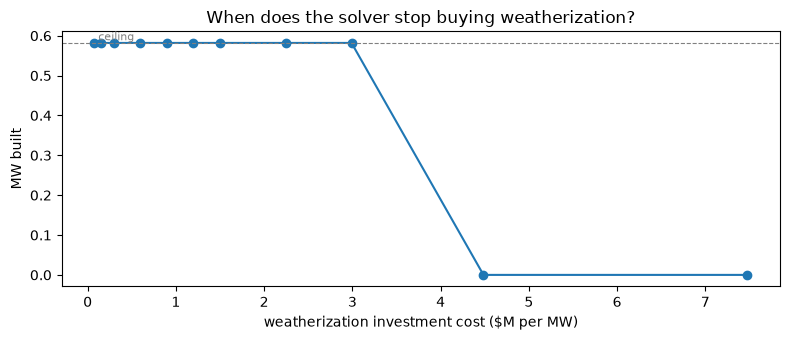

In [24]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(sweep.investment_musd_per_mw, sweep.built_mw, marker='o')
ax.axhline(dsm_p_nom_max, ls='--', lw=0.8, color='grey')
ax.text(sweep.investment_musd_per_mw.min(), dsm_p_nom_max, ' ceiling',
        va='bottom', fontsize=8, color='grey')
ax.set_xlabel('weatherization investment cost ($M per MW)')
ax.set_ylabel('MW built')
ax.set_title('When does the solver stop buying weatherization?')
plt.tight_layout(); plt.show()


Read the three regions off that curve:

- **Cheap** — the solver builds the ceiling. Every MW on offer is worth having.
- **In between** — a declining segment, and this is the interesting one. The *first* negawatt displaces your most expensive hour; the last one displaces a cheap hour. Marginal value falls as you build more, so the resource retreats gradually rather than vanishing.
- **Expensive** — nothing. The measure is worth less than it costs.

If your curve has no middle region, your ceiling is probably binding so hard that the measure never gets to be marginal. Say so — that is a finding, not a failure.

Now find the crossing by bisection rather than by squinting at the plot. **Bracket it from the sweep you already ran** — one price where it still builds, one where it does not — rather than from a guessed range.

That is not fussiness. A bisection whose bracket does not actually contain the answer will still return a number: the edge of your own bracket, looking exactly like a result. It is the same trap as a balance that closes to exactly zero in SB1 — an artifact of how you set the problem up, wearing the costume of a finding.

So the cell below refuses to guess. If your measure built at every price, or at none of them, it stops and tells you which way to move the range.


In [25]:
# Bracket from the sweep you just ran, rather than from a guessed range.
built_rows = sweep[sweep.built_mw > BUILT_TOL]
empty_rows = sweep[sweep.built_mw <= BUILT_TOL]

if built_rows.empty:
    raise ValueError(
        'The solver built nothing at ANY price in your sweep, so there is '
        'no threshold inside it. Your measure is worth less than the '
        'cheapest price you tested - lower the multipliers above and '
        're-run. Do NOT report the bottom of the range as the threshold.')
if empty_rows.empty:
    raise ValueError(
        'The solver built the measure at EVERY price in your sweep, so '
        'the threshold is above your range - raise the multipliers above '
        'and re-run. Do NOT report the top of the range as the threshold.')

lo = built_rows.investment_musd_per_mw.max() * 1e6   # still builds here
hi = empty_rows.investment_musd_per_mw.min() * 1e6   # builds nothing here
print(f'threshold is between ${lo:,.0f} and ${hi:,.0f} per MW - refining')

for _ in range(16):
    mid = (lo + hi) / 2
    n_b = build_1node_model(site_demand_mw, 'bisect')
    n_b.add('Carrier', 'demand-side resource', color='seagreen')
    n_b.add('Generator', 'weatherization', bus='electricity',
            carrier='demand-side resource',
            p_max_pu=dsm_p_max_pu, p_nom_max=dsm_p_nom_max,
            capital_cost=annuity(DSM_DISCOUNT, DSM_LIFETIME) * mid,
            marginal_cost=0.0, p_nom_extendable=True)
    n_b.optimize(solver_name=SOLVER, env=ENV)
    if n_b.generators.p_nom_opt['weatherization'] > BUILT_TOL:
        lo = mid
    else:
        hi = mid

if abs(lo - built_rows.investment_musd_per_mw.max() * 1e6) < 1e-9:
    raise ValueError(
        'The bisection never moved its lower bound, so this is the edge '
        'of your bracket rather than a converged threshold. That is the '
        'exact failure this section warns about - check BUILT_TOL against '
        'the size of your ceiling before trusting any number here.')

print(f'weatherization drops out of the optimum at')
print(f'  ${lo:,.0f} per MW of installed cost')
print(f'  = ${annuity(DSM_DISCOUNT, DSM_LIFETIME) * lo:,.0f} per MW-year annualised')


threshold is between $2,990,457 and $4,485,685 per MW - refining


INFO:linopy.model: Solve problem using Gurobi solver


INFO:linopy.model:Solver options:
 - log_to_console: False


INFO:linopy.io:Writing objective.


Writing constraints.:   0%|          | 0/22 [00:00<?, ?it/s]

...

obj: 70088 rows, 32127 columns, 134722 nonzeros


Set parameter LogToConsole to value 0


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 32127 primals, 70090 duals
Objective: 4.62e+06
Solver: gurobi
Runtime: 1.94s
Dual bound: 4.62e+06
Solver model: available
Solver message: 2



INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-ext-e-lower, Store-ext-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Store-energy_balance were not assigned to the network.


weatherization drops out of the optimum at
  $4,240,603 per MW of installed cost
  = $363,888 per MW-year annualised


**That number is the answer to Part 3.** It is what one MW of avoided heating and cooling load is worth to this system: the capacity it lets you not build, plus the energy it lets you not generate, over the measure's life.

You did not assume it. The model computed it, and it would move if your demand shape, your weather, or your generation costs moved.

Now compare it against what the retrofit actually costs. If the real cost sits below that line the measure is worth doing — and your `DSM_INVESTMENT` should have built something back in 3.2. If it sits above, you have just quantified by how much the measure misses, which is a more useful sentence than "weatherization is a good idea".


### 3.4 Your technology — specify one of the three

Everything above used weatherization. Your assignment is to specify **one** of the three as a resource. Each needs the same three numbers, and each takes them from a different place:

| | displaces | ceiling | availability `p_max_pu` |
|---|---|---|---|
| **Weatherization** | heating + cooling | cut % × peak of those two | heating + cooling load |
| **Efficiency upgrade (SEER)** | cooling only | (1 − SEER_old/SEER_new) × peak cooling | cooling load |
| **Heat pump, replacing electric resistance** | heating only | (1 − 1/COP) × peak heating | heating load |

**The heat pump has a fourth case, and it is not a resource at all.** If the building currently heats with *gas*, switching to a heat pump **adds** electric load rather than removing it. It is not a negawatt generator; it is a new `Load`. The saving happens in gas, which is outside this model's boundary entirely — so this model cannot see the benefit and will report the switch as pure cost.

If you choose that case, say so explicitly, and say what you would have to bring inside the boundary to evaluate it honestly. That is a full-marks answer, and it is Module 0B's question arriving early.


In [ ]:
# --- specify ONE, then re-run 3.2 and 3.3 with it ---
# DSM_NAME, DSM_END_USES, DSM_CEILING_FRACTION = 'weatherization', ['heating', 'cooling'], 0.30
# DSM_NAME, DSM_END_USES, DSM_CEILING_FRACTION = 'seer upgrade',   ['cooling'], 1 - 10 / 15
# DSM_NAME, DSM_END_USES, DSM_CEILING_FRACTION = 'heat pump',      ['heating'], 1 - 1 / 2.8

if 'DSM_NAME' not in globals():
    raise NameError(
        'Uncomment exactly ONE of the three lines above. Part 3 asks you '
        'to choose a demand-side technology and defend the three numbers '
        'that define it - the notebook will not choose for you.')

my_share = end_uses[DSM_END_USES].sum(axis=1) / daily_kwh
my_saveable_kw = pd.Series(
    own_demand_kw.values
    * my_share.reindex(own_demand_kw.index.floor('D')).values,
    index=own_demand_kw.index)
my_saveable_mw = align_to_reference_calendar(my_saveable_kw, ts.index) * N_PREMISES

my_p_max_pu = (my_saveable_mw / my_saveable_mw.max()).clip(0, 1)
my_p_nom_max = DSM_CEILING_FRACTION * my_saveable_mw.max()

print(f'{DSM_NAME}: acts on {DSM_END_USES}')
print(f'  peak addressable load  {my_saveable_mw.max():,.1f} MW')
print(f'  ceiling                {my_p_nom_max:,.1f} MW')
print()
print('Re-run 3.2 and 3.3 with my_p_max_pu and my_p_nom_max, and report')
print('the price at which YOUR technology enters and drops out.')


**Report:**
- The three numbers defining your resource — cost, availability, ceiling — each with a source.
- The price at which it enters the optimum, and the price at which it drops out.
- **What it displaced.** Compare the build in `r_own` against your DSM run: which technology got smaller, and does that make sense given *when* your measure is available?
- The difference between 3.1 and 3.2 in your own words — what question did each one answer?
- One demand-side technology you did **not** model, and what data you would need to add it (appliance-level submetering for a cooking-fuel switch, say, or an envelope audit for a deeper weatherization estimate).


---

*Before class: this notebook worked from metered interval data rather than a forecast. What can you say about this building that you could not say about a region, and what did you give up to get it?*

